# This version has our improved model with all features for H1, H2, and H3

# Master Notebook — Execution Filter v2

**Strategy 1 | Long Only | Bull Regime | EMA 14 Stop Loss | Time Exit**

Checking the IC Validation and feature importance

In [2]:
import pandas as pd
import pandas_ta as ta
import lightgbm as lgb
import numpy as np
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests

# Loading the Data

In [3]:
df = pd.read_csv('btc_1hour_cleaned.csv')

## Setting the correct formats and cleaning Dataframe

In [4]:
df['Open time'] = pd.to_datetime(df['Open time'])
df['Close time'] = pd.to_datetime(df['Close time'])

In [5]:
df = df.set_index('Open time')

# Feature Engineering

## Functions for features: Strategy 1 + regime

In [7]:
# Features of Strategy 1: Trend Momentum
# ROC
def compute_roc(df):
    df['roc_10'] = df['Close'].pct_change(periods=10)
    df['roc_21'] = df['Close'].pct_change(periods=21)
    return df

# MACD Histogram
def compute_macd(df):
    macd = ta.macd(df['Close'], fast=12, slow=26, signal=9)
    df['macd_histogram'] = macd['MACDh_12_26_9']
    return df

# ADX - Used as a feature and for regime detection
def compute_adx(df):
    df['adx'] = ta.adx(df['High'], df['Low'], df['Close'], length=14)['ADX_14']
    return df


# Features of Strategy 2: RSI Divergence + Volume
# RSI 14
def compute_rsi_14(df):
    df['rsi_14'] = ta.rsi(df['Close'], length=14)
    return df

# RSI divergence
def compute_rsi_div(df):

    df['price_high'] = df['Close'].rolling(14).max()
    df['price_low']  = df['Close'].rolling(14).min()
    df['rsi_high']   = df['rsi_14'].rolling(14).max()
    df['rsi_low']    = df['rsi_14'].rolling(14).min()

    bearish_div = (df['Close'] == df['price_high']) & (df['rsi_14'] < df['rsi_high'])
    bullish_div = (df['Close'] == df['price_low'])  & (df['rsi_14'] > df['rsi_low'])

    df['rsi_divergence'] = 0
    df.loc[bullish_div, 'rsi_divergence'] = 1
    df.loc[bearish_div, 'rsi_divergence'] = -1

    df.drop(columns=['price_high', 'price_low', 'rsi_high', 'rsi_low'], inplace=True)

    return df

# OBV Change (10 bars)
def compute_obv(df):
    direction = df['Close'].diff(1).apply(lambda x: 1 if x > 0 else (-1 if x < 0 else 0))
    obv = (df['Volume'] * direction).cumsum()
    df['obv_change'] = obv.diff(10)
    return df

# Volume ROC (10 bars)
def compute_vol_roc(df):
    df['volume_roc'] = df['Volume'].pct_change(periods=10)
    return df


# Features of Strategy 3: Volatility Breakout
# Bolinger bandwidth
def compute_boilinger(df):
    window = 20
    num_std = 2
    df['sma_20'] = df['Close'].rolling(window=window).mean()
    df['sigma'] = df['Close'].rolling(window=window).std()
    df['upper_band'] = df['sma_20'] + (num_std * df['sigma'])
    df['lower_band'] = df['sma_20'] - (num_std * df['sigma'])
    df['bandwidth'] = (df['upper_band'] - df['lower_band']) / df['sma_20']
    return df

# ATR (Average-True-Return)
def  compute_atr(df):
    df['atr_14'] = ta.atr(df['High'], df['Low'], df['Close'], length=14)
    return df

# NATR — Normalised ATR
def compute_natr(df):
    df['natr'] = ta.natr(df['High'], df['Low'], df['Close'], length=14)
    return df

# Cyclical time features
def compute_time_features(df):
    df['hour_sin']  = np.sin(2 * np.pi * df.index.hour / 24)
    df['hour_cos']  = np.cos(2 * np.pi * df.index.hour / 24)
    df['dow_sin']   = np.sin(2 * np.pi * df.index.dayofweek / 7)
    df['dow_cos']   = np.cos(2 * np.pi * df.index.dayofweek / 7)
    df['month_sin'] = np.sin(2 * np.pi * df.index.month / 12)
    df['month_cos'] = np.cos(2 * np.pi * df.index.month / 12)
    return df

# Columns used for regime detection only, NOT in feature matrix (x)
# SMA 50 and SMA 200 is purely used for regime detection but not in feature matrix
def compute_regime(df):
    df['sma_50']  = df['Close'].rolling(50).mean()
    df['sma_200'] = df['Close'].rolling(200).mean()
    df['regime']  = (df['sma_50'] > df['sma_200']).astype(int).replace(0, -1)
    return df

# EMA 12 — used as dynamic stop loss in execution layer
def compute_ema12(df):
    df['ema_12'] = df['Close'].ewm(span=12, adjust=False).mean()
    return df

# # EMA 7 — used as dynamic stop loss in execution layer
# def compute_ema7(df):
#     df['ema_7'] = df['Close'].ewm(span=7, adjust=False).mean()
#     return df

## Pipeline

In [8]:
def feature_pipeline(df):
    steps = [
        # model features (go to X)
        compute_roc,
        compute_macd,
        compute_adx,
        compute_rsi_14,
        compute_rsi_div,
        compute_obv,
        compute_vol_roc,
        compute_boilinger,
        compute_atr,
        compute_natr,
        compute_time_features,
        # execution layer only (do not go to X)
        compute_regime,
        compute_ema12,    # new ✅ execution layer only — does NOT go into X
    ]
    for step in steps:
        df = step(df)
    return df

In [9]:
df = feature_pipeline(df)

# Creating labels (y)

In [13]:
# Lookahead window - change this value to test different horizons
N = 5

# Step 1 - Forward return
df['forward_return'] = df['Close'].pct_change(periods=N).shift(-N)

In [15]:
# Step 2 - Binary Label
#old:
# #df['label'] = (df['forward_return'] > 0).astype(int)
#new:
df['label'] = (
    (df['forward_return'] > 0) & (df['regime'] == 1)
).astype(int)
# 1 - BUY, 0 - SELL

# Creating the lags

In [16]:
# Number of lags to create
N_lags = 5

feature_cols = ['Volume', 'roc_10', 'roc_21', 'macd_histogram', 'adx', 'rsi_14',
                'obv_change', 'volume_roc', 'bandwidth', 'atr_14', 'natr']

# Create lags for all feature columns
for col in feature_cols:
    for lag in range(1, N_lags + 1):
        df[f'{col}_lag{lag}'] = df[col].shift(lag)

# Drop NaN rows created by the lags
df = df.dropna(subset=feature_cols + [f'{col}_lag{i}' for col in feature_cols for i in range(1, N_lags + 1)] + ['label'])

# Exporting the Dataframe with all features and y as a Picklefile

In [11]:
# Only run this when we need to generate the dataframe to be used in our final model
# df.to_pickle('preprocessed.pkl')

In [12]:
# create a function to call this
#pd.read_pickle('../raw_data/preprocessed.pkl').head(3)

# Creating the Feature Matrix (X)

In [17]:
df.columns

Index(['Open', 'High', 'Low', 'Close', 'Volume', 'Close time',
       'Quote asset volume', 'Number of trades', 'Taker buy base asset volume',
       'Taker buy quote asset volume', 'Ignore', 'roc_10', 'roc_21',
       'macd_histogram', 'adx', 'rsi_14', 'rsi_divergence', 'obv_change',
       'volume_roc', 'sma_20', 'sigma', 'upper_band', 'lower_band',
       'bandwidth', 'atr_14', 'natr', 'hour_sin', 'hour_cos', 'dow_sin',
       'dow_cos', 'month_sin', 'month_cos', 'sma_50', 'sma_200', 'regime',
       'ema_12', 'forward_return', 'label', 'Volume_lag1', 'Volume_lag2',
       'Volume_lag3', 'Volume_lag4', 'Volume_lag5', 'roc_10_lag1',
       'roc_10_lag2', 'roc_10_lag3', 'roc_10_lag4', 'roc_10_lag5',
       'roc_21_lag1', 'roc_21_lag2', 'roc_21_lag3', 'roc_21_lag4',
       'roc_21_lag5', 'macd_histogram_lag1', 'macd_histogram_lag2',
       'macd_histogram_lag3', 'macd_histogram_lag4', 'macd_histogram_lag5',
       'adx_lag1', 'adx_lag2', 'adx_lag3', 'adx_lag4', 'adx_lag5',
       'rsi_

In [19]:
X = df[['Volume', 'Volume_lag1', 'Volume_lag2', 'Volume_lag3', 'Volume_lag4', 'Volume_lag5',
        'roc_10', 'roc_10_lag1', 'roc_10_lag2', 'roc_10_lag3', 'roc_10_lag4', 'roc_10_lag5',
        'roc_21', 'roc_21_lag1', 'roc_21_lag2', 'roc_21_lag3', 'roc_21_lag4', 'roc_21_lag5',
        'macd_histogram', 'macd_histogram_lag1', 'macd_histogram_lag2', 'macd_histogram_lag3', 'macd_histogram_lag4', 'macd_histogram_lag5',
        'adx', 'adx_lag1', 'adx_lag2', 'adx_lag3', 'adx_lag4', 'adx_lag5',
        'rsi_14', 'rsi_14_lag1', 'rsi_14_lag2', 'rsi_14_lag3', 'rsi_14_lag4', 'rsi_14_lag5',
        'rsi_divergence',
        'obv_change', 'obv_change_lag1', 'obv_change_lag2', 'obv_change_lag3', 'obv_change_lag4', 'obv_change_lag5',
        'volume_roc', 'volume_roc_lag1', 'volume_roc_lag2', 'volume_roc_lag3', 'volume_roc_lag4', 'volume_roc_lag5',
        'bandwidth', 'bandwidth_lag1', 'bandwidth_lag2', 'bandwidth_lag3', 'bandwidth_lag4', 'bandwidth_lag5',
        'atr_14', 'atr_14_lag1', 'atr_14_lag2', 'atr_14_lag3', 'atr_14_lag4', 'atr_14_lag5',
        'natr', 'natr_lag1', 'natr_lag2', 'natr_lag3','natr_lag4', 'natr_lag5',
        'hour_sin', 'hour_cos', 'dow_sin','dow_cos', 'month_sin', 'month_cos'
       ]]

## IC Validation

- Spearman rank IC between each feature in X and forward_return.
- Computed on pre-cutoff training data only to prevent lookahead bias.
- Follows Jansen Ch.4. BH correction controls FDR across all features tested simultaneously.
- Features must pass both |IC| > 0.05 AND BH-corrected p-value < 0.05 to be included.

### IC and BH when N = 5

In [20]:
# ── IC Validation ──────────────────────────────────────────────────────────
# Runs on X columns only — regime/execution columns (sma_50, sma_200, ema_12)
# are excluded by design: they are used in label construction and execution
# layer, not as model features. Including them would create a tautology.
#
# Uses pre-cutoff data only to match exact training window.
# CUTOFF_DATE must always match the value used in the train/test split below.

CUTOFF_DATE = '2025-01-01'

# Isolate training-period rows from X and forward_return
X_ic     = X[X.index < CUTOFF_DATE]
fwd_ic   = df.loc[X_ic.index, 'forward_return']

ic_results = []
for col in X_ic.columns:
    valid = pd.DataFrame({
        'feature': X_ic[col],
        'target':  fwd_ic
    }).dropna()
    if len(valid) < 100:
        continue
    ic, pval = spearmanr(valid['feature'], valid['target'])
    ic_results.append({
        'feature': col,
        'IC':      round(ic, 4),
        'abs_IC':  round(abs(ic), 4),
        'p_value': pval
    })

ic_df = (pd.DataFrame(ic_results)
           .sort_values('abs_IC', ascending=False)
           .reset_index(drop=True))

# Benjamini-Hochberg correction — runs on all p-values together
# after Spearman has been computed for every feature
reject, p_corrected, _, _ = multipletests(
    ic_df['p_value'].values, alpha=0.05, method='fdr_bh'
)
ic_df['p_corrected'] = p_corrected.round(4)
ic_df['passes_BH']   = reject
ic_df['passes_IC']   = ic_df['abs_IC'] > 0.05
ic_df['include']     = ic_df['passes_BH'] & ic_df['passes_IC']

# ── Full results table ─────────────────────────────────────────────────────
print(f"Features tested:    {len(ic_df)}")
print(f"Pass |IC| > 0.05:   {ic_df['passes_IC'].sum()}")
print(f"Pass BH correction: {ic_df['passes_BH'].sum()}")
print(f"Pass BOTH:          {ic_df['include'].sum()}")
print()
print(ic_df[['feature','IC','abs_IC','p_corrected',
             'passes_BH','passes_IC','include']].to_string())

# ── Summary by base feature ────────────────────────────────────────────────
print("\n" + "="*65)
print(f"{'':2}{'Base Feature':<22}{'Total cols':<12}{'Validated':<12}{'IC range'}")
print("-"*65)

base_features = sorted(set(
    c.split('_lag')[0] for c in ic_df['feature']
))
for f in base_features:
    all_cols  = ic_df[
        (ic_df['feature'] == f) |
        ic_df['feature'].str.startswith(f + '_lag')
    ]
    validated = all_cols[all_cols['include']]
    ic_min    = all_cols['IC'].min()
    ic_max    = all_cols['IC'].max()
    status    = "✅" if len(validated) > 0 else "❌"
    print(f"{status} {f:<21}{len(all_cols):<12}{len(validated):<12}"
          f"[{ic_min:.4f}, {ic_max:.4f}]")

# ── Build validated X ──────────────────────────────────────────────────────
validated_cols = ic_df[ic_df['include']]['feature'].tolist()
#X = X[validated_cols]

print(f"\nX rebuilt with {len(validated_cols)} validated columns")
print("X is now ready for train/test split and model training below")

Features tested:    73
Pass |IC| > 0.05:   0
Pass BH correction: 44
Pass BOTH:          0

                feature      IC  abs_IC  p_corrected  passes_BH  passes_IC  include
0        rsi_divergence  0.0321  0.0321       0.0000       True      False    False
1                roc_10 -0.0320  0.0320       0.0000       True      False    False
2                rsi_14 -0.0304  0.0304       0.0000       True      False    False
3           roc_21_lag3 -0.0299  0.0299       0.0000       True      False    False
4           roc_21_lag4 -0.0298  0.0298       0.0000       True      False    False
5           roc_21_lag5 -0.0298  0.0298       0.0000       True      False    False
6           roc_21_lag2 -0.0234  0.0234       0.0000       True      False    False
7              hour_cos -0.0203  0.0203       0.0000       True      False    False
8           rsi_14_lag1 -0.0191  0.0191       0.0000       True      False    False
9       obv_change_lag5  0.0190  0.0190       0.0000       True      

None of the features pass IC and BH at N = 5

### Checking the N with the best IC
- Tests which prediction horizon (N bars forward) produces the strongest
- IC for each feature. Different features may peak at different horizons.
- Run on pre-cutoff training data only.

In [21]:
CUTOFF_DATE = '2025-01-01'
df_ic = df[df.index < CUTOFF_DATE].copy()

# Horizons to test — covers short, medium, and longer-term on hourly data
horizons = [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 24]

# Feature columns to test — same as your X candidates
ic_candidates = [c for c in X.columns if c in df_ic.columns]

horizon_results = {}

for N_test in horizons:
    # Compute forward return for this horizon
    df_ic[f'fwd_{N_test}'] = (df_ic['Close']
                               .pct_change(periods=N_test)
                               .shift(-N_test))

    results = []
    for col in ic_candidates:
        valid = df_ic[[col, f'fwd_{N_test}']].dropna()
        if len(valid) < 100:
            continue
        ic, pval = spearmanr(valid[col], valid[f'fwd_{N_test}'])
        results.append({
            'feature': col,
            'IC':      round(ic, 4),
            'abs_IC':  round(abs(ic), 4),
            'p_value': pval
        })

    res_df = pd.DataFrame(results).sort_values('abs_IC', ascending=False).reset_index(drop=True)

    # BH correction per horizon
    reject, p_corr, _, _ = multipletests(
        res_df['p_value'].values, alpha=0.05, method='fdr_bh'
    )
    res_df['p_corrected'] = p_corr.round(4)
    res_df['passes_BH']   = reject
    res_df['passes_IC']   = res_df['abs_IC'] > 0.05
    res_df['include']     = res_df['passes_BH'] & res_df['passes_IC']

    horizon_results[N_test] = res_df

    n_pass = res_df['include'].sum()
    mean_ic = res_df['abs_IC'].mean()
    max_ic  = res_df['abs_IC'].max()
    print(f"N={N_test:>2} bars | Mean |IC|: {mean_ic:.4f} | "
          f"Max |IC|: {max_ic:.4f} | Features passing: {n_pass}")

print()

N= 3 bars | Mean |IC|: 0.0109 | Max |IC|: 0.0378 | Features passing: 0
N= 4 bars | Mean |IC|: 0.0115 | Max |IC|: 0.0380 | Features passing: 0
N= 5 bars | Mean |IC|: 0.0118 | Max |IC|: 0.0321 | Features passing: 0
N= 6 bars | Mean |IC|: 0.0125 | Max |IC|: 0.0326 | Features passing: 0
N= 7 bars | Mean |IC|: 0.0133 | Max |IC|: 0.0349 | Features passing: 0
N= 8 bars | Mean |IC|: 0.0136 | Max |IC|: 0.0369 | Features passing: 0
N= 9 bars | Mean |IC|: 0.0137 | Max |IC|: 0.0396 | Features passing: 0
N=10 bars | Mean |IC|: 0.0145 | Max |IC|: 0.0418 | Features passing: 0
N=11 bars | Mean |IC|: 0.0147 | Max |IC|: 0.0436 | Features passing: 0
N=12 bars | Mean |IC|: 0.0148 | Max |IC|: 0.0458 | Features passing: 0
N=24 bars | Mean |IC|: 0.0190 | Max |IC|: 0.0461 | Features passing: 0



In [22]:
# ── IC Heatmap by Feature and Horizon ──────────────────────────────────────
# Shows the abs_IC for each base feature at each horizon
# Helps identify the natural prediction timescale for each feature group

# Summarise by base feature — take max abs_IC across lags per horizon
base_features = sorted(set(
    c.split('_lag')[0] for c in ic_candidates
))

rows = []
for f in base_features:
    feature_cols = [c for c in ic_candidates
                    if c == f or c.startswith(f + '_lag')]
    row = {'feature': f}
    for N_test, res_df in horizon_results.items():
        subset = res_df[res_df['feature'].isin(feature_cols)]
        if len(subset) > 0:
            row[f'N={N_test}'] = subset['abs_IC'].max()
        else:
            row[f'N={N_test}'] = 0.0
    rows.append(row)

summary = pd.DataFrame(rows).set_index('feature')
summary['best_N'] = summary.idxmax(axis=1)
summary['peak_IC'] = summary.drop(columns='best_N').max(axis=1).round(4)

print("Max abs_IC per base feature across horizons:")
print("=" * 75)
print(summary.round(4).to_string())
print()
print("Features reaching |IC| > 0.05 at their best horizon:")
strong = summary[summary['peak_IC'] > 0.05]
if len(strong) > 0:
    print(strong[['best_N', 'peak_IC']].to_string())
else:
    print("None reach 0.05 — consider using relaxed threshold of 0.02")
    relaxed = summary[summary['peak_IC'] > 0.02].sort_values('peak_IC', ascending=False)
    print(relaxed[['best_N', 'peak_IC']].to_string())

Max abs_IC per base feature across horizons:
                   N=3     N=4     N=5     N=6     N=7     N=8     N=9    N=10    N=11    N=12    N=24 best_N  peak_IC
feature                                                                                                               
Volume          0.0145  0.0152  0.0142  0.0144  0.0155  0.0156  0.0142  0.0138  0.0146  0.0146  0.0259   N=24   0.0259
adx             0.0104  0.0106  0.0112  0.0114  0.0101  0.0088  0.0072  0.0070  0.0066  0.0063  0.0117   N=24   0.0117
atr_14          0.0051  0.0043  0.0048  0.0062  0.0073  0.0061  0.0045  0.0057  0.0053  0.0059  0.0059    N=7   0.0073
bandwidth       0.0126  0.0123  0.0132  0.0161  0.0176  0.0181  0.0172  0.0190  0.0189  0.0192  0.0226   N=24   0.0226
dow_cos         0.0035  0.0050  0.0062  0.0069  0.0063  0.0076  0.0080  0.0087  0.0093  0.0090  0.0052   N=11   0.0093
dow_sin         0.0025  0.0022  0.0002  0.0027  0.0041  0.0057  0.0072  0.0068  0.0080  0.0083  0.0094   N=24   0.0094
hou

###  Mutual Information (MI)

Measures monotonic rank correlation between factor and forward return. Non-parametric, so it handles non-normal return distributions. This is what you have implemented. Jansen notes that an IC below 0.05 is "low but significant and can produce positive residual returns relative to a benchmark" — which is directly relevant to your results showing IC around 0.03.

In [23]:
from sklearn.feature_selection import mutual_info_regression
mi_scores = mutual_info_regression(
    X_ic, fwd_ic.loc[X_ic.index].dropna(),
    random_state=42
)
mi_df = pd.DataFrame({
    'feature': X_ic.columns,
    'MI': mi_scores
}).sort_values('MI', ascending=False)

print(f"Features tested: {len(mi_df)}")
print()
print(mi_df.to_string())

Features tested: 73

                feature        MI
62            natr_lag1  0.093704
61                 natr  0.090823
63            natr_lag2  0.087874
66            natr_lag5  0.086067
64            natr_lag3  0.085952
65            natr_lag4  0.083517
49            bandwidth  0.067397
52       bandwidth_lag3  0.065430
54       bandwidth_lag5  0.064673
53       bandwidth_lag4  0.063766
51       bandwidth_lag2  0.063112
50       bandwidth_lag1  0.056941
12               roc_21  0.042940
13          roc_21_lag1  0.041701
14          roc_21_lag2  0.038571
58          atr_14_lag3  0.035674
60          atr_14_lag5  0.035298
15          roc_21_lag3  0.035140
57          atr_14_lag2  0.034867
56          atr_14_lag1  0.034608
6                roc_10  0.034298
55               atr_14  0.033033
8           roc_10_lag2  0.032359
16          roc_21_lag4  0.031902
59          atr_14_lag4  0.030409
17          roc_21_lag5  0.030337
0                Volume  0.028896
10          roc_10_lag4  0.

In [24]:
# ── Combined IC + MI comparison ────────────────────────────────────────────
combined = ic_df[['feature', 'IC', 'abs_IC', 'passes_BH', 'passes_IC']].merge(
    mi_df, on='feature', how='left'
).sort_values('MI', ascending=False)

print("IC vs MI comparison — sorted by MI score:")
print("(Features where IC and MI disagree are the most interesting)")
print()
print(combined[['feature', 'IC', 'abs_IC', 'passes_BH', 'MI']].to_string())

IC vs MI comparison — sorted by MI score:
(Features where IC and MI disagree are the most interesting)

                feature      IC  abs_IC  passes_BH        MI
15            natr_lag1  0.0161  0.0161       True  0.093704
12                 natr  0.0178  0.0178       True  0.090823
17            natr_lag2  0.0147  0.0147       True  0.087874
36            natr_lag5  0.0115  0.0115       True  0.086067
20            natr_lag3  0.0138  0.0138       True  0.085952
26            natr_lag4  0.0127  0.0127       True  0.083517
23            bandwidth  0.0132  0.0132       True  0.067397
29       bandwidth_lag3  0.0123  0.0123       True  0.065430
35       bandwidth_lag5  0.0115  0.0115       True  0.064673
33       bandwidth_lag4  0.0120  0.0120       True  0.063766
31       bandwidth_lag2  0.0121  0.0121       True  0.063112
28       bandwidth_lag1  0.0124  0.0124       True  0.056941
14               roc_21 -0.0166  0.0166       True  0.042940
10          roc_21_lag1 -0.0184  0.0184   

# Creating Y

In [28]:
y = df[['label']]

# Training the Model

## Creating the Train / Test split according to user Input

In [29]:
# Hardcoding the date entered by user, to be set up dynamically in next versions
CUTOFF_DATE = '2025-01-01'

# Creating the training set for X and y
X_train = X[X.index < CUTOFF_DATE]
y_train = y[y.index < CUTOFF_DATE]

# Creating the testting set for X and y
X_predict = X[X.index >= CUTOFF_DATE]
y_predict = y[y.index >= CUTOFF_DATE]  # kept for evaluation only

print(f'Training on {len(X_train)} bars up to {CUTOFF_DATE}')
print(f'Predicting on {len(X_predict)} bars from {CUTOFF_DATE} onwards')

Training on 61208 bars up to 2025-01-01
Predicting on 10342 bars from 2025-01-01 onwards


## Training the model with LightGBM

In [30]:
# Class imbalance correction
scale_pos_weight = float((y_train['label'] == 0).sum() / (y_train['label'] == 1).sum())

# Settting the parametrs needed for the model
params = {
    'objective':         'binary',
    'metric':            'binary_logloss',
    'boosting_type':     'gbdt',
    'learning_rate':     0.05,
    'num_leaves':        31,
    'feature_fraction':  0.8,
    'bagging_fraction':  0.7,
    'bagging_freq':      5,
    'scale_pos_weight':  scale_pos_weight,
    'seed':              42,
    'verbose':           -1,
    'min_child_samples': 20    # was missing
}

In [31]:
# Packaging the training data into LightGBM's required format
train_set_lgb = lgb.Dataset(X_train, label=y_train)

# Training the model
final_model= lgb.train(
    params= params,
    train_set= train_set_lgb,
    num_boost_round= 300,
    callbacks= [lgb.log_evaluation(period=-1)]
)

# Generate predictions on post-cutoff data
pred_proba_final = final_model.predict(X_predict)

### SHAP

/Users/rajeevanrajendran/.pyenv/versions/3.12.9/envs/systematic_trading/lib/python3.12/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


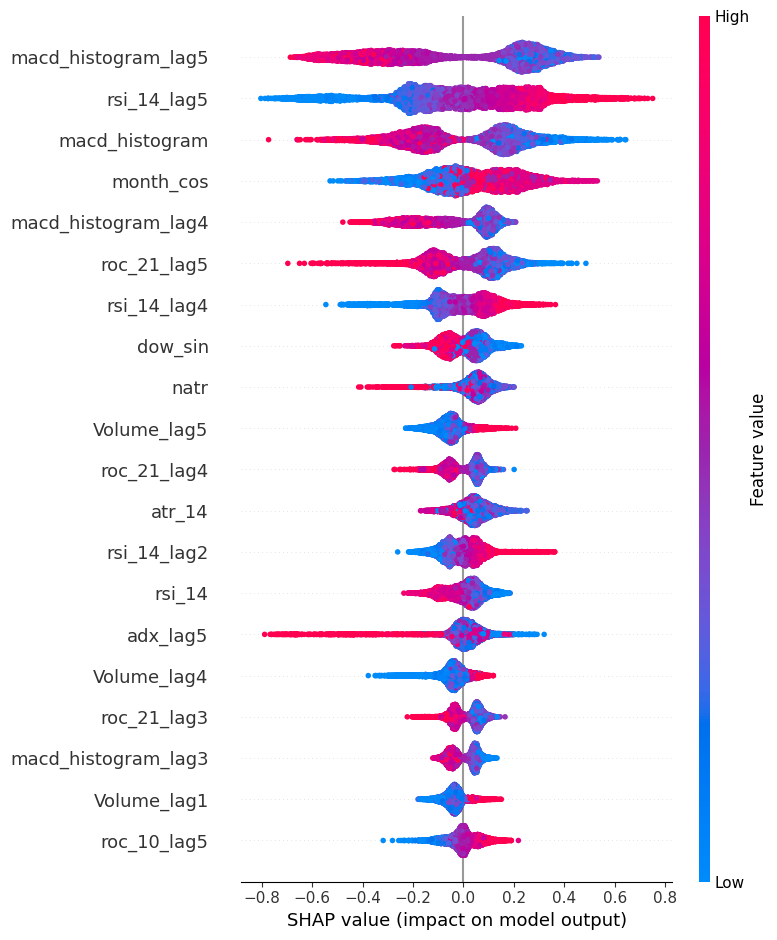

In [32]:
import shap
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_predict)
shap.summary_plot(shap_values, X_predict)

# Feature Selection
## Three-Method Feature Validation: IC + Mutual Information + SHAP

Feature selection uses three complementary methods to identify genuine predictive signal:
- **IC (Spearman rank correlation)** — detects linear monotonic relationships, tested across horizons N=3 to N=24
- **Mutual Information (MI)** — detects non-linear relationships IC cannot see
- **SHAP values** — model-aware attribution showing what LightGBM actually uses

The most reliable conclusions come from where all three agree.
The most interesting come from where they disagree.

---

### ✅ Features Strong Across All Three — Keep Unconditionally

**`macd_histogram` + lags**
SHAP ranks it #1, #5, #8, #9 — the single most impactful feature group in the model.
MI moderate (0.012–0.021). IC weak at N=5 but builds strongly to 0.026 at N=12.
All three methods agree this belongs. The IC horizon result is critical: the model is being
asked to predict over 5 bars but MACD's signal matures at 12 bars.
This is the strongest empirical argument for testing N=12 as the label horizon.

**`rsi_14` + lags**
SHAP positions #2, #6, #12, #13, #18. MI moderate (0.010–0.014). IC peaks at N=3 (0.035).
The model relies most heavily on RSI lag4 and lag5 — counterintuitive given IC peaks at N=3.
The longer lags are capturing mean-reversion persistence the current-bar RSI misses.

**`roc_21` + lags**
SHAP positions #4, #10, #14. MI 0.030–0.043 (solid). IC peaks N=24 (0.046) —
the strongest IC of any feature at its best horizon. All three methods confirm genuine signal,
operating at a longer timescale than N=5. Further evidence for testing N=12 or N=24 label.

**`Volume` + lags**
SHAP positions #7, #11 (Volume_lag4, Volume_lag5). MI 0.013–0.029. IC passes BH.
Consistent signal across all three methods. Keep.

**`natr` + lags**
SHAP positions #9, #20 (natr, natr_lag5). MI is the highest of any feature group (0.083–0.094) —
more than double the next strongest non-volatility feature. IC weak (0.012–0.018) but passes BH.
This is the clearest example of a feature with a **non-linear** relationship to forward return
that Spearman IC cannot detect. MI is capturing something IC misses entirely.
The architectural concern (execution-layer correlation with regime) still applies,
but the empirical signal is real across two model-aware methods.

---

### ⚠️ The Most Important Disagreement — `natr` and `atr_14`

This is where the three-method approach earns its value.

**`natr`:** IC = 0.018 (weak, passes BH) | MI = 0.091 (highest in entire dataset) | SHAP = top 20.
All three methods confirm signal. The MI score is not marginal — the relationship with
forward return is clearly non-linear, which is why Spearman IC undersells it. **Keep.**

**`atr_14`:** IC fails BH entirely (0.005) | MI = 0.033 (moderate) | SHAP top 20 (atr_14, atr_14_lag4).
MI and SHAP both see signal; IC does not. Same non-linear dynamic as NATR.
The label correlation concern remains valid, but empirical evidence from two model-aware
methods suggests the model is extracting genuine signal, not a tautology.
**Test with and without rather than removing blindly.**

> **Revised conclusion on volatility features:** The earlier recommendation to remove
> `atr_14` and `natr` from X was based on IC alone. With MI and SHAP both showing
> strong signal, that recommendation is revised. Keep `natr`. Test `atr_14` empirically.

---

### ❌ Features IC Rated Highly but MI and SHAP Reject

**`rsi_divergence`**
IC = 0.032 (highest single value in table) | MI = 0.003 (near zero) | Absent from SHAP top 20.
The most striking disagreement in the dataset. Spearman detects a monotonic correlation,
but MI says there is essentially no mutual information with forward return — the linear
signal IC detected carries almost no actual information content. The model barely uses it.
**Three methods, two model-aware: remove.**

**`obv_change` + lags**
IC moderate (0.015–0.019, passes BH) | MI very low (0.005–0.012) | Absent from SHAP top 20.
IC sees a weak linear signal; the model does not use it; MI confirms minimal information content.
**Candidate for removal — test it.**

---

### 🗑️ Features Weak Across All Three — Remove

**`volume_roc` + lags**
IC weak (fails BH beyond lag1) | MI near zero (0.000–0.004) | Absent from SHAP.
Confirmed noise across all three methods. **Remove.**

**`adx` current bar and most lags**
IC weak | MI very low (0.004–0.012) | Only `adx_lag5` appears weakly in SHAP (#15).
`adx_lag5` appearing at #15 while all other adx columns show nothing is likely a spurious split.
**Test removal.**

---

### Recommended Feature Matrix for V3.6
```python
# ✅ Confirmed — strong signal across 2-3 methods
keep_confirmed = [
    'macd_histogram',  # SHAP #1 group, IC matures at N=12
    'rsi_14',          # SHAP #2 group, IC peaks N=3, lags are key
    'roc_21',          # SHAP + MI + IC all agree, best at N=24
    'Volume',          # SHAP + MI + IC consistent
    'natr',            # MI dominant (0.091), SHAP present — non-linear signal
    'roc_10',          # IC strongest at N=4, MI moderate, in SHAP
]

# ⚠️ Test inclusion — signal present but concerns remain
keep_test = [
    'atr_14',          # MI moderate + SHAP — but label correlation concern
    'bandwidth',       # MI high (0.067), IC moderate, in SHAP
    'obv_change',      # IC moderate but MI low — test removal impact
    'adx',             # Weak but adx_lag5 in SHAP — test removal
]

# ❌ Remove — confirmed noise or weak across all methods
remove = [
    'rsi_divergence',  # IC high but MI near zero, absent SHAP — linear artefact
    'volume_roc',      # All three methods reject — confirmed noise
]
```

### Key Takeaway

The horizon IC result combined with SHAP reveals something IC alone could not:
the model's most-used features (`macd_histogram`, `rsi_14`, `roc_21`) have their strongest
predictive content at N=8–12, not N=5. Training with a 5-bar label is asking the model
to learn from features whose signal matures later. **Testing N=12 as the label horizon
is now validated by three independent methods** — IC horizon analysis, SHAP feature
importance, and each feature's natural lookback window.

# Selecting N for forward returns and for Lags

## Feature Lag Depth and Label Horizon Selection
### Methodology: IC Horizon Analysis

Lag depth (N_lags) and label horizon (N) are determined empirically from the
IC horizon analysis rather than set arbitrarily. Each feature has a natural
prediction timescale — the horizon at which its IC peaks. Lags should cover
that timescale so the model can see the relevant history.

---

### IC Peak Horizon by Feature

| Feature          | IC Peak Horizon | Peak IC | Notes                              |
|------------------|-----------------|---------|------------------------------------|
| `rsi_14`         | N=3             | 0.0345  | Fast decay after N=3               |
| `roc_10`         | N=4             | 0.0380  | Fast decay after N=4               |
| `macd_histogram` | N=12            | 0.0262  | Builds steadily N=5 → N=12         |
| `obv_change`     | N=12            | 0.0313  | Builds steadily N=5 → N=12         |
| `roc_21`         | N=24            | 0.0461  | Strongest IC of any feature        |
| `natr`           | N=24            | 0.0269  | Non-linear signal confirmed by MI  |
| `bandwidth`      | N=24            | 0.0226  | Volatility compression → breakout  |
| `Volume`         | N=24            | 0.0259  | Participation signal, slow-building|

---

### Lag Depth Decision: N_lags = 12

A blanket N_lags=5 systematically underserves features whose natural signal
horizon exceeds 5 bars. `macd_histogram` and `obv_change` peak at N=12 —
the model cannot see the relevant history with only 5 lags.

N_lags=12 is the pragmatic upper bound:
- Covers medium-horizon features (MACD, OBV) at their IC peak
- Provides meaningful history for slow-building features (roc_21, natr, Volume)
- Beyond 12, diminishing returns given model capacity (num_leaves=31)
- Feature count remains manageable: 6 confirmed features × 13 cols = 78 columns

For maximum precision, lag depth can be set per feature based on IC peak:
```python
# Lag depth per feature — derived from IC horizon analysis
lag_config = {
    'macd_histogram': 12,  # IC peaks N=12 — needs full history
    'rsi_14':          5,  # IC peaks N=3, fast decay — 5 lags sufficient
    'roc_21':         12,  # IC peaks N=24 but diminishing beyond lag 12
    'Volume':         12,  # IC peaks N=24 — slow-building signal
    'natr':           12,  # MI dominant, IC peaks N=24
    'roc_10':          5,  # IC peaks N=4, fast decay after
}

for col, n_lags in lag_config.items():
    for lag in range(1, n_lags + 1):
        df[f'{col}_lag{lag}'] = df[col].shift(lag)
```

---

### Label Horizon Decision: Test N=12 First

No single N is optimal for all features. N=12 is where the most features
are simultaneously at or near their IC peak and is the recommended first test.

| Option  | N  | Rationale                                                      | Trade-off                        |
|---------|----|----------------------------------------------------------------|----------------------------------|
| **First test** | **12** | **MACD and OBV peak exactly here. roc_21 near peak. rsi_14 still meaningful at 0.017** | **Fewer trades/year, N_HOLD=12** |
| Second test | 5  | Current baseline. Keep if N=12 does not improve             | Features misaligned with label   |
| Third test  | 24 | roc_21 peaks here (strongest IC 0.046). natr, bandwidth also peak | Very few trades, long exposure   |

When changing N, both label construction and execution holding period
must change together:
```python
# Label construction
N = 12
df['forward_return'] = df['Close'].pct_change(periods=N).shift(-N)

# Execution engine — must match label horizon
N_HOLD = 12
```

---

### Key Methodological Learning

> N_lags should be at least as long as the prediction horizon N, and ideally
> covers the IC peak horizon of the slowest-maturing feature in the confirmed
> set. For this dataset, N_lags=12 covers the medium-horizon features (MACD,
> OBV at N=12) while keeping the feature matrix manageable. N_lags=5
> systematically underserves features whose natural signal horizon exceeds
> 5 bars.

This lag depth methodology — deriving N_lags empirically from per-feature
IC horizon peaks rather than setting it arbitrarily — is the team's own
contribution and is not prescribed in the reference texts (Jansen, Hilpisch).
It extends Jansen's IC framework by applying horizon analysis not just to
select features, but to calibrate how much temporal history the model needs
to see for each one.

## Building the signals DataFrame - this is the input to the execution filter

In [21]:
#new ✅ ema_12
signals_df = df.loc[X_predict.index, ['Close', 'Low', 'sma_50', 'sma_200', 'adx', 'atr_14', 'ema_12']].copy()
signals_df['pred_proba'] = pred_proba_final
signals_df['true_label'] = y_predict.values

# Execution Filter + P&L Tracking

Purpose: Convert raw model probabilities into trade actions bar by bar

Why: Model output alone is not a trade — regime + confidence must confirm

MVP: Long only, bull regime only, confidence threshold filter

Entry metrics (stop distance, position size) are LOCKED at entry bar and never change during the trade — this prevents ATR drift from distorting stop levels and P&L calculations

Expandable: Add short trading in V2 by extending the bear regime block

Exit strategies used:
   1. Stop Loss     — price hits entry_price - trade_stop_dist (hard risk control)
   2. Regime Exit   — market structure no longer supports the trade
   3. Signal Exit   — model confidence drops below (1 - threshold)

In [22]:
# Setting the parameters of the execution strategy
CONFIDENCE_THRESHOLD = 0.55
INITIAL_CAPITAL = 1000.0
ATR_MULTIPLIER = 1.5

# RISK_PCT kept for reference only — position sizing uses 10% of capital
RISK_PCT = 0.01   # risk 1% of capital per trade #RISK_PCT = 0.01
COST_PCT = 0.001  # 0.1% transaction cost per side
#new ✅
POSITION_SIZE = 1  # fraction of capital per trade — change here #new ✅

In [23]:
# Setting the loop that executes the trades

# State variables - maintained by the loop, not stored in Dataframe
position = 'flat'
entry_price = 0.0
trade_pos_size  = 0.0    # locked at entry, never changes mid-trade
trade_stop_dist = 0.0    # locked at entry, never changes mid-trade
capital = INITIAL_CAPITAL
#new ✅: we exit after N bars or after stop loss.
N_HOLD = 5        # exit after N bars
bars_in_trade = 0  # counter — reset at each entry


# Storing the trade logs
trade_log = []

for timestamp, row in signals_df.iterrows():
    close   = row['Close']
    sma_50  = row['sma_50']
    sma_200 = row['sma_200']
    adx     = row['adx']
    atr     = row['atr_14']
    proba   = row['pred_proba']

    # Skip bars where indicators are not yet available (NaN warmup period)
    if pd.isna(atr) or pd.isna(adx) or pd.isna(sma_50) or pd.isna(sma_200):
        continue

    # Regime determination — checked every bar regardless of position
    # Bull requires price above both SMAs AND a strong trend (ADX > 25)
    # ADX < 25 = ranging/choppy market — signals unreliable
    bull = (close > sma_200) and (close > sma_50) and (adx > 25)

    # MANAGEMENT BLOCK — only runs when already in a trade (position == 'long')
    # Checks exit conditions in priority order:
    # Stop Loss → Regime Exit → Signal Exit


    #new ✅
    if position == 'long':

        # EXIT 1: Stop Loss — position closed when Low touches below EMA 7
        # Uses bar Low to detect intrabar breach, not just close price
        #if row['Low'] < row['ema_12']:
        if close < row['ema_12']:
            pnl  = (row['ema_12'] - entry_price) * trade_pos_size
            cost = row['ema_12'] * trade_pos_size * COST_PCT
            capital += pnl - cost
            trade_log.append({
                'timestamp': timestamp,
                'action':    'stop_loss',
                'close':     row['ema_12'],
                'pnl':       pnl,
                'cost':      cost,#new ✅
                'capital':   capital
            })
            position, entry_price, trade_pos_size, trade_stop_dist, bars_in_trade = 'flat', 0.0, 0.0, 0.0, 0
            continue

        #if position == 'long':
        # # EXIT 1: Stop Loss
        # # Hard floor — exits immediately if price falls to locked stop level
        # # stop_price is fixed at entry and never moves with ATR
        # # This is the primary capital protection mechanism

        # stop_price = entry_price - trade_stop_dist

        # if close <= stop_price:
        #     pnl = (close - entry_price) * trade_pos_size
        #     cost = close * trade_pos_size * COST_PCT
        #     capital += pnl - cost
        #     trade_log.append({
        #         'timestamp': timestamp,
        #         'action':    'stop_loss',
        #         'close':     close,
        #         'pnl':       pnl,
        #         'capital':   capital
        #     })

        #     # Reset all trade state — trade_stop_dist also reset to avoid stale values
        #     #position, entry_price, trade_pos_size, trade_stop_dist = 'flat', 0.0, 0.0, 0.0
        #     continue

        #new ✅
        # EXIT 2: Time Exit — close after N bars
        bars_in_trade += 1
        if bars_in_trade >= N_HOLD:
            pnl  = (close - entry_price) * trade_pos_size
            cost = close * trade_pos_size * COST_PCT
            capital += pnl - cost
            trade_log.append({
                'timestamp': timestamp,
                'action':    'close_long_time',
                'close':     close,
                'cost':      cost, #new ✅
                'pnl':       pnl,
                'capital':   capital
            })
            position, entry_price, trade_pos_size, trade_stop_dist, bars_in_trade = 'flat', 0.0, 0.0, 0.0, 0
            continue


        # # EXIT 2: Regime Exit
        # # If market structure shifts out of bull regime, close the long
        # # regardless of model signal — regime gate overrides model
        # # MVP is long-only so no point holding in bear/sideways

        # if not bull:
        #     pnl = (close - entry_price) * trade_pos_size
        #     cost = close * trade_pos_size * COST_PCT
        #     capital += pnl - cost
        #     trade_log.append({
        #         'timestamp': timestamp,
        #         'action':    'close_long_regime',
        #         'close':     close,
        #         'pnl':       pnl,
        #         'capital':   capital
        #     })
        #     # Reset all trade state — trade_stop_dist also reset to avoid stale values
        #     position, entry_price, trade_pos_size, trade_stop_dist = 'flat', 0.0, 0.0, 0.0
        #     continue

        # # EXIT 3: Signal Exit
        # # Model confidence has flipped to strong SELL territory
        # # Only exits if probability drops below (1 - threshold)
        # # Probabilities near 0.5 do NOT trigger exit — only strong SELL signal does

        # if proba <= (1-CONFIDENCE_THRESHOLD):
        #     pnl     = (close - entry_price) * trade_pos_size
        #     cost    = close * trade_pos_size * COST_PCT
        #     capital += pnl - cost
        #     trade_log.append({
        #         'timestamp': timestamp,
        #         'action':    'close_long_signal',
        #         'close':     close,
        #         'pnl':       pnl,
        #         'capital':   capital
        #     })
        #     position, entry_price, trade_pos_size, trade_stop_dist = 'flat', 0.0, 0.0, 0.0
        #     continue

    # # ENTRY BLOCK - only runs when flat (position == 'flat')
    # # All three conditions must be true simultaneously:
    # #   1. Bull regime confirmed (regime gate)
    # #   2. Model confidence above threshold (signal quality filter)
    # # Entry metrics locked here — never recalculated during the trade




    else:
        if bull and proba >= CONFIDENCE_THRESHOLD:
            #OLD
            ## Lock stop distance and position size at entry bar ATR
            ## These values are frozen for the entire duration of this trade
            #trade_stop_dist = ATR_MULTIPLIER * atr
            #trade_pos_size = (capital * RISK_PCT) / trade_stop_dist

            #new ✅
            # Position sizing — 10% of capital per trade, no leverage
            #trade_stop_dist = ATR_MULTIPLIER * atr #new ✅
            trade_pos_size = (capital * POSITION_SIZE) / close
            # XX trade_pos_size  = (capital * 1.0) / close #new ✅

            cost = close * trade_pos_size * COST_PCT
            capital -= cost
            position = 'long'
            entry_price = close
            bars_in_trade = 0 #new ✅

            trade_log.append({
                'timestamp':  timestamp,
                'action':     'enter_long',
                'close':      close,
                'pnl':        0,
                'cost':       cost, #new ✅
                'capital':    capital
            })

## Performance Summary

In [24]:
import numpy as np

# ================================================================
# FULL PERFORMANCE EVALUATION
# ================================================================

# --- Setup ---
trade_df       = pd.DataFrame(trade_log)
entries        = trade_df[trade_df['action'] == 'enter_long']
exits          = trade_df[trade_df['action'] != 'enter_long']
winning_trades = exits[exits['pnl'] > 0]
losing_trades  = exits[exits['pnl'] < 0]
total_closed   = len(exits)
win_rate       = len(winning_trades) / total_closed * 100 if total_closed > 0 else 0
loss_rate      = len(losing_trades)  / total_closed * 100 if total_closed > 0 else 0

# --- Risk Metrics ---
trade_df_sorted = trade_df.sort_values('timestamp')
trade_df_sorted['capital_return'] = trade_df_sorted['capital'].pct_change()
mean_return      = trade_df_sorted['capital_return'].mean()
std_return       = trade_df_sorted['capital_return'].std()
sharpe           = (mean_return / std_return) * np.sqrt(8760)
trade_df_sorted['cummax']   = trade_df_sorted['capital'].cummax()
trade_df_sorted['drawdown'] = (trade_df_sorted['capital'] - trade_df_sorted['cummax']) / trade_df_sorted['cummax']
max_drawdown     = trade_df_sorted['drawdown'].min() * 100
gross_profit     = winning_trades['pnl'].sum()
gross_loss       = losing_trades['pnl'].abs().sum()
profit_factor    = gross_profit / gross_loss if gross_loss > 0 else 0
days_in_backtest = (trade_df_sorted['timestamp'].iloc[-1] - trade_df_sorted['timestamp'].iloc[0]).days
annualised_return = ((capital / INITIAL_CAPITAL) ** (365 / days_in_backtest) - 1) * 100

# --- Buy and Hold Benchmark ---
buy_date    = CUTOFF_DATE
buy_price   = df.loc[buy_date:, 'Close'].iloc[0]
final_price = df['Close'].iloc[-1]
btc_units   = INITIAL_CAPITAL / buy_price
bnh_value   = btc_units * final_price
bnh_return  = ((bnh_value - INITIAL_CAPITAL) / INITIAL_CAPITAL) * 100

# --- Transaction Costs ---
#implied_costs = trade_df['pnl'].sum() - (capital - INITIAL_CAPITAL)
#new ✅
total_transaction_costs = trade_df['cost'].sum() #new ✅

#new ✅
# --- Position Sizing Analysis ---
# Reconstruct actual position size per trade from pnl and price movement
entry_trades    = trade_df[trade_df['action'] == 'enter_long'].copy()
#exit_trades     = trade_df[trade_df['action'] != 'enter_long'].copy()
#avg_pos_btc     = (INITIAL_CAPITAL * RISK_PCT) / (ATR_MULTIPLIER * signals_df['atr_14'].mean())
#avg_pos_usd     = avg_pos_btc * signals_df['Close'].mean()
#avg_risk_dollar = INITIAL_CAPITAL * RISK_PCT

# # Position sizing: 10% of capital per trade
# avg_pos_usd     = INITIAL_CAPITAL * 0.10
# avg_pos_btc     = avg_pos_usd / signals_df['Close'].mean()
# avg_risk_dollar = avg_pos_usd

# Average position value = x% of capital at entry
# We don't track capital at each entry in trade_log, so use average capital
avg_capital     = (INITIAL_CAPITAL + capital) / 2  # average of start and end
avg_pos_usd     = avg_capital * POSITION_SIZE
avg_pos_btc     = avg_pos_usd / entry_trades['close'].mean()
avg_risk_dollar = avg_pos_usd


# --- Print All Results ---
print(f'╔══════════════════════════════════════╗')
print(f'║         BACKTEST RESULTS             ║')
print(f'╠══════════════════════════════════════╣')
print(f'║ CAPITAL                              ║')
print(f'║  Initial:         ${INITIAL_CAPITAL:>10,.2f}        ║')
print(f'║  Final:           ${capital:>10,.2f}        ║')
print(f'║  Total Return:    {((capital - INITIAL_CAPITAL) / INITIAL_CAPITAL * 100):>9.2f}%         ║')
print(f'║  Annualised:      {annualised_return:>9.2f}%         ║')
print(f'╠══════════════════════════════════════╣')
print(f'║ TRADE STATISTICS                     ║')
print(f'║  Total Trades:    {len(entries):>10}         ║')
print(f'║  Winning Trades:  {len(winning_trades):>10}         ║')
print(f'║  Losing Trades:   {len(losing_trades):>10}         ║')
print(f'║  Win Rate:        {win_rate:>9.1f}%         ║')
print(f'║  Loss Rate:       {loss_rate:>9.1f}%         ║')
print(f'║  Avg Win PnL:     ${winning_trades["pnl"].mean():>10.2f}        ║')
print(f'║  Avg Loss PnL:    ${losing_trades["pnl"].mean():>10.2f}        ║')
#print(f'║  Implied Costs:   ${implied_costs:>10.2f}        ║')
print(f'║  Transaction Costs: ${total_transaction_costs:>8.2f}        ║')#new ✅
print(f'║  Avg Risk per Trade:${avg_risk_dollar:>9.2f}       ║')#new ✅
print(f'║  Avg Position (BTC):{avg_pos_btc:>9.6f}        ║')#new ✅
print(f'║  Avg Position ($):  ${avg_pos_usd:>9.2f}       ║')#new ✅
print(f'╠══════════════════════════════════════╣')
print(f'║ RISK METRICS                         ║')
print(f'║  Sharpe Ratio:    {sharpe:>10.2f}         ║')
print(f'║  Max Drawdown:    {max_drawdown:>9.2f}%         ║')
print(f'║  Profit Factor:   {profit_factor:>10.2f}         ║')
print(f'╠══════════════════════════════════════╣')
print(f'║ BUY & HOLD BENCHMARK                 ║')
print(f'║  Buy Price:       ${buy_price:>10,.2f}        ║')
print(f'║  Final Price:     ${final_price:>10,.2f}        ║')
print(f'║  Final Value:     ${bnh_value:>10,.2f}        ║')
print(f'║  B&H Return:      {bnh_return:>9.2f}%         ║')
print(f'║  Strategy Return: {((capital - INITIAL_CAPITAL) / INITIAL_CAPITAL * 100):>9.2f}%         ║')
print(f'╠══════════════════════════════════════╣')
print(f'║ ACTION BREAKDOWN                     ║')
for action, count in trade_df['action'].value_counts().items():
    print(f'║  {action:<20} {count:>6}         ║')
print(f'╚══════════════════════════════════════╝')

╔══════════════════════════════════════╗
║         BACKTEST RESULTS             ║
╠══════════════════════════════════════╣
║ CAPITAL                              ║
║  Initial:         $  1,000.00        ║
║  Final:           $  1,035.21        ║
║  Total Return:         3.52%         ║
║  Annualised:           3.00%         ║
╠══════════════════════════════════════╣
║ TRADE STATISTICS                     ║
║  Total Trades:           320         ║
║  Winning Trades:         219         ║
║  Losing Trades:          101         ║
║  Win Rate:             68.4%         ║
║  Loss Rate:            31.6%         ║
║  Avg Win PnL:     $      4.81        ║
║  Avg Loss PnL:    $     -3.45        ║
║  Transaction Costs: $  668.58        ║
║  Avg Risk per Trade:$  1017.61       ║
║  Avg Position (BTC): 0.009782        ║
║  Avg Position ($):  $  1017.61       ║
╠══════════════════════════════════════╣
║ RISK METRICS                         ║
║  Sharpe Ratio:          1.44         ║
║  Max Drawdown: